# Final Project Part 1: Likelihood-Based Deep Generative Models

This notebook contains a complete coding homework assignment aligned with the course slides on:

1. Autoregressive models  
2. Maximum-likelihood learning  
3. Variational autoencoders  
4. Normalizing flows  

The assignment uses **PyTorch** and is structured as executable sections.

## Dataset

Use **MNIST**.

For the autoregressive model, binarize the images.

For the VAE and normalizing flow parts, use normalized pixel values in [0,1].

# Part 0: Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 200kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.24MB/s]


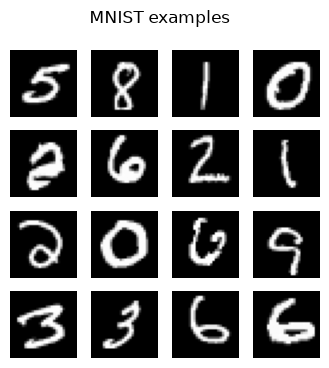

In [3]:
def show_images(x, title=None, n=16):
    x = x.detach().cpu()
    x = x[:n]
    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x[i].view(28, 28), cmap="gray")
        ax.axis("off")
    if title is not None:
        plt.suptitle(title)
    plt.show()


x_batch, _ = next(iter(train_loader))
show_images(x_batch, title="MNIST examples")

# Part 1: Autoregressive Bernoulli Model

The autoregressive factorization is:

Each pixel is modeled as a Bernoulli random variable.

## Task 1.1: Binarize MNIST

In [4]:
def binarize(x):
    return (x > 0.5).float()

## Task 1.2: Implement a Masked Linear Layer

A masked linear layer prevents the model from seeing future pixels.

In [5]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, mask):
        super().__init__(in_features, out_features)
        self.register_buffer("mask", mask)

    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)

## Task 1.3: Create Autoregressive Masks

For a simple MADE-style model, output dimension \(i\) may depend only on input pixels \(< i\).

In [6]:
def create_ar_mask(input_dim, hidden_dim):
    input_order = torch.arange(input_dim)
    hidden_order = torch.randint(low=0, high=input_dim - 1, size=(hidden_dim,))

    mask1 = (hidden_order[:, None] >= input_order[None, :]).float()
    mask2 = (input_order[:, None] > hidden_order[None, :]).float()

    return mask1, mask2

## Task 1.4: Implement the Autoregressive Model

In [7]:
class AutoregressiveBernoulliModel(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        super().__init__()

        mask1, mask2 = create_ar_mask(input_dim, hidden_dim)

        self.net = nn.Sequential(
            MaskedLinear(input_dim, hidden_dim, mask1),
            nn.ReLU(),
            MaskedLinear(hidden_dim, input_dim, mask2)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        logits = self.net(x)
        return logits

    def log_prob(self, x):
        x = x.view(x.size(0), -1)
        logits = self.forward(x)
        log_prob = -F.binary_cross_entropy_with_logits(
            logits, x, reduction="none"
        )
        return log_prob.sum(dim=1)

    def sample(self, num_samples):
        x = torch.zeros(num_samples, 784).to(device)

        for i in range(784):
            logits = self.forward(x)
            probs = torch.sigmoid(logits[:, i])
            x[:, i] = torch.bernoulli(probs)

        return x.view(num_samples, 1, 28, 28)

## Task 1.5: Train the Autoregressive Model

In [8]:
ar_model = AutoregressiveBernoulliModel().to(device)
optimizer = torch.optim.Adam(ar_model.parameters(), lr=1e-3)

num_epochs = 10
ar_train_nll = []

for epoch in range(num_epochs):
    ar_model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = binarize(x).to(device)

        loss = -ar_model.log_prob(x).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    ar_train_nll.append(avg_loss)
    print(f"Epoch {epoch+1}, Negative Log-Likelihood (NLL): {avg_loss:.4f}")

Epoch 1, Negative Log-Likelihood (NLL): 207.4084
Epoch 2, Negative Log-Likelihood (NLL): 123.4893
Epoch 3, Negative Log-Likelihood (NLL): 106.3744
Epoch 4, Negative Log-Likelihood (NLL): 98.7577
Epoch 5, Negative Log-Likelihood (NLL): 94.3835
Epoch 6, Negative Log-Likelihood (NLL): 91.5620
Epoch 7, Negative Log-Likelihood (NLL): 89.5619
Epoch 8, Negative Log-Likelihood (NLL): 88.0528
Epoch 9, Negative Log-Likelihood (NLL): 86.8925
Epoch 10, Negative Log-Likelihood (NLL): 85.9582


## Task 1.6: Evaluate Test NLL

In [9]:
def evaluate_ar(model, data_loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, _ in data_loader:
            x = binarize(x).to(device)
            loss = -model.log_prob(x).mean()
            total_loss += loss.item()
    return total_loss / len(data_loader)


ar_test_nll = evaluate_ar(ar_model, test_loader)
print("Autoregressive Test NLL:", ar_test_nll)

Autoregressive Test NLL: 85.82777356497849


## Task 1.7: Generate Samples

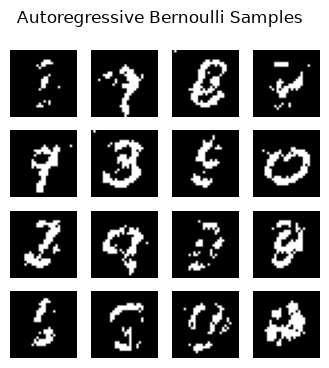

In [10]:
ar_model.eval()
with torch.no_grad():
    samples = ar_model.sample(16)

show_images(samples, title="Autoregressive Bernoulli Samples")

## Questions: Autoregressive Model

Answer in your report:

1. Why is sampling from this model sequential?
2. Why is likelihood evaluation easy?
3. What is the role of the ordering of pixels?
4. Explain why autoregressive models are powerful but slow at generation time.

## Answers

### 1. Why is sampling from this model sequential?

Sampling from the autoregressive model is sequential because the joint distribution is factored as a product of conditional distributions:

$$p(x) = \prod_{i=1}^{D} p(x_i \mid x_1, \dots, x_{i-1})$$

To draw a sample for pixel $i$, the values of all preceding pixels must already be available, since the probability distribution of $x_i$ depends on them. This means generation must proceed one pixel at a time — first sample $x_1$ from a marginal, then $x_2$ given $x_1$, then $x_3$ given $x_1, x_2$, and so on, up to $x_{784}$. The masked linear layers enforce this constraint during both training and inference by zeroing out weights that would allow future pixels to influence earlier predictions. As a result, sampling requires 784 sequential forward passes, which is inherently non-parallelizable.

### 2. Why is likelihood evaluation easy?

Likelihood evaluation is easy because the autoregressive model explicitly factorizes the joint distribution into conditional probabilities:

$$p(x) = \prod_{i=1}^{D} p(x_i \mid x_1, \dots, x_{i-1})$$

Taking the logarithm turns the product into a sum:

$$\log p(x) = \sum_{i=1}^{D} \log p(x_i \mid x_1, \dots, x_{i-1})$$

For a training image, all pixel values are already known, so the model can calculate the conditional probability for every pixel in one forward pass. The masks ensure that each pixel prediction only depends on preceding pixels. For binary pixels, each term is a Bernoulli log-likelihood:

$$\log p(x_i \mid x_{<i}) = x_i\log(\hat p_i) + (1-x_i)\log(1-\hat p_i)$$

Thus, likelihood evaluation is not just taking a logarithm: the model first predicts all conditional probabilities, then computes their log-probabilities and adds them together. Unlike generation, this calculation does not require sequential sampling.

### 3. What is the role of the ordering of pixels?

The ordering determines which pixels are treated as previous pixels and which pixels are treated as future pixels. In this model, the image is flattened using a raster-scan order: pixels are processed from left to right, and rows are processed from top to bottom. Therefore, the conditional probability of each pixel may depend only on pixels that appear earlier in this ordering.

This ordering is mainly a convenient convention, not a rule based on how human vision works. Other orderings are possible, but they define different conditional dependencies and can affect the model's performance. A good ordering can make nearby or related pixels available earlier, while a poor ordering may make the dependencies harder to learn. The ordering also affects the sequence used during generation, although the model can still represent a joint distribution for any fixed ordering.

### 4. Explain why autoregressive models are powerful but slow at generation time.

Autoregressive models are powerful because they model the joint distribution as a sequence of conditional distributions. Each prediction can use the information from all previously generated pixels, allowing the model to capture complex dependencies and detailed relationships within the image. They also provide an explicit likelihood, which makes it possible to evaluate how probable a data example is.

However, generation is slow because the pixels must be generated one at a time. The next pixel cannot be sampled until all earlier pixels have been generated. Therefore, an image with $D$ pixels requires approximately $D$ sequential prediction steps. Larger images have more pixels and consequently require more steps, and later predictions may depend on a larger context. This sequential process prevents efficient parallel generation, even though the predictions for all pixels can be computed in parallel during training when the complete image is already available.

# Part 2: Variational Autoencoder

## Task 2.1: Implement the Encoder

In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

## Task 2.2: Implement the Decoder

In [12]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super().__init__()

        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        logits = self.fc_out(h)
        return logits

## Task 2.3: Implement the VAE

In [13]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z)
        return logits, mu, logvar

    def sample(self, num_samples):
        z = torch.randn(num_samples, self.latent_dim).to(device)
        logits = self.decoder(z)
        probs = torch.sigmoid(logits)
        return probs.view(num_samples, 1, 28, 28)

## Task 2.4: Implement the ELBO Loss

Use a Bernoulli decoder.

In [14]:
def vae_loss(logits, x, mu, logvar):
    x = x.view(x.size(0), -1)

    reconstruction_loss = F.binary_cross_entropy_with_logits(
        logits, x, reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    loss = reconstruction_loss + kl_divergence

    return loss, reconstruction_loss, kl_divergence

## Task 2.5: Train the VAE

In [15]:
vae = VAE(latent_dim=20).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

num_epochs = 10
vae_loss_curve = []
vae_recon_curve = []
vae_kl_curve = []

for epoch in range(num_epochs):
    vae.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        logits, mu, logvar = vae(x)
        loss, recon_loss, kl = vae_loss(logits, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl.item()

    n = len(train_loader.dataset)
    vae_loss_curve.append(total_loss / n)
    vae_recon_curve.append(total_recon / n)
    vae_kl_curve.append(total_kl / n)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {total_loss/n:.4f}, "
        f"Recon: {total_recon/n:.4f}, "
        f"KL: {total_kl/n:.4f}"
    )

Epoch 1, Loss: 164.8003, Recon: 149.3148, KL: 15.4854
Epoch 2, Loss: 121.4857, Recon: 99.1792, KL: 22.3065
Epoch 3, Loss: 114.5744, Recon: 90.7018, KL: 23.8726
Epoch 4, Loss: 111.5944, Recon: 87.1241, KL: 24.4703
Epoch 5, Loss: 109.7894, Recon: 85.0081, KL: 24.7813
Epoch 6, Loss: 108.6520, Recon: 83.7106, KL: 24.9414
Epoch 7, Loss: 107.7844, Recon: 82.7650, KL: 25.0194
Epoch 8, Loss: 107.1088, Recon: 81.9697, KL: 25.1390
Epoch 9, Loss: 106.6345, Recon: 81.4304, KL: 25.2041
Epoch 10, Loss: 106.1225, Recon: 80.9101, KL: 25.2124


## Task 2.6: Generate Samples

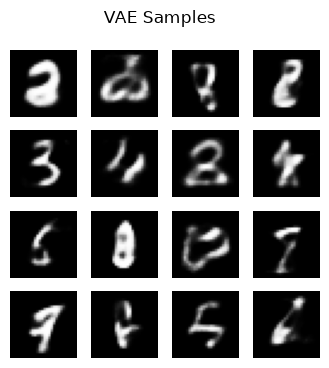

In [16]:
vae.eval()
with torch.no_grad():
    samples = vae.sample(16)

show_images(samples, title="VAE Samples")

## Task 2.7: Latent Space Interpolation

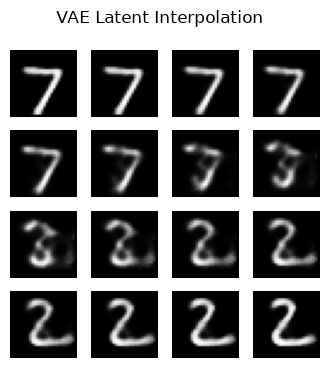

In [17]:
vae.eval()

x_batch, y_batch = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    mu, logvar = vae.encoder(x_batch)
    z = mu

z1 = z[0]
z2 = z[1]

alphas = torch.linspace(0, 1, steps=16).to(device)
z_interp = torch.stack([(1 - a) * z1 + a * z2 for a in alphas])

with torch.no_grad():
    logits = vae.decoder(z_interp)
    imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)

show_images(imgs, title="VAE Latent Interpolation")

## Questions: VAE

Answer in your report:

1. Why do we need the reparameterization trick?
2. What does the KL term encourage?
3. What happens if the KL term becomes almost zero?
4. Why is the VAE likelihood not directly tractable, unlike the autoregressive model?
5. Compare VAE samples with autoregressive samples.

## Answers: VAE

### 1. Why do we need the reparameterization trick?

The encoder of a VAE produces the mean $\mu$ and standard deviation $\sigma$ of a Gaussian distribution over the latent variable $z$. We need to sample from this distribution during training, but directly sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ introduces a random operation through which ordinary backpropagation cannot easily pass. Consequently, the reconstruction loss would not provide useful gradients for updating the encoder.

The reparameterization trick rewrites the sampling operation as:

$$z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0,I)$$

The randomness is isolated in $\epsilon$, while $z$ is computed from $\mu$ and $\sigma$ using differentiable operations. This allows gradients to flow through $z$ and update the encoder with standard backpropagation. The trick therefore does not remove the randomness; it makes randomized sampling compatible with gradient-based learning.

The randomness is important because it allows the VAE to represent uncertainty and map each input to a region in latent space rather than one fixed point. It also helps create a smooth latent space from which we can sample new data. Without this randomness, the model would behave more like a regular deterministic autoencoder and would lose much of the VAE's generative advantage.

### 2. What does the KL term encourage?

The KL-divergence term compares the encoder's latent distribution $q(z|x)$ with the standard normal distribution $\mathcal{N}(0,I)$. During training, the VAE minimizes this term, so it encourages the latent distribution for each input to remain close to the standard normal prior. In practice, this encourages the latent means to stay near zero and the latent variances to stay near one, while discouraging unrelated or isolated regions in latent space.

As a result, the latent space becomes smooth and well-organized: similar inputs tend to have nearby representations, and points sampled from $\mathcal{N}(0,I)$ are likely to be meaningful inputs for the decoder. This is what allows the VAE to generate new examples by sampling from the standard normal distribution. The KL term therefore acts as a regularizer, while the reconstruction term ensures that the latent representation still preserves useful information about the input.

### 3. What happens if the KL term becomes almost zero?

If the KL term becomes almost zero for all inputs, then the encoder distributions $q(z|x)$ become almost identical to the standard normal distribution $\mathcal{N}(0,I)$. Consequently, the latent variable $z$ contains very little information about the particular input image and is approximately independent of $x$. The sampled latent vectors may therefore appear random with respect to the input.

This situation is known as posterior collapse. The decoder may learn to ignore the latent variable, causing different images to have similar or blurry reconstructions and reducing the model's ability to represent meaningful features in the latent space. Thus, although a small KL term indicates that the latent distributions match the prior well, making it too small can prevent the latent space from carrying useful information.

### 4. Why is the VAE likelihood not directly tractable, unlike the autoregressive model?

For a VAE, the likelihood of an observed image is obtained by marginalizing over all possible latent variables:

$$p(x) = \int p(x|z)p(z)\,dz$$

This integral is generally not tractable because the latent space is continuous and usually high-dimensional. There are infinitely many possible values of $z$, and the decoder must be considered for all of them. The VAE therefore uses the evidence lower bound (ELBO) as a tractable approximation to the log-likelihood.

In an autoregressive model, the likelihood is factorized directly into conditional probabilities:

$$p(x) = \prod_i p(x_i|x_{<i})$$

For a given observed image, all pixel values are known, so each conditional probability can be evaluated directly and the log-likelihood can be computed. Thus, the VAE's difficulty comes from integrating over unobserved latent variables, whereas the autoregressive model evaluates a sequence of observable conditional probabilities.

### 5. Compare VAE samples with autoregressive samples.

The autoregressive samples have crisp, hard-edged digits with strictly binary black-and-white pixel values. However, they may contain salt-and-pepper noise, such as isolated white pixels in the background or missing pixels within a digit. This suggests that the model captures sharp local pixel dependencies but still makes occasional individual pixel errors.

The VAE samples are smoother and more blurry, with soft digit boundaries and grayscale pixel values between the background and the center of each digit. The VAE does not show the same isolated-pixel noise, but its samples lose some sharp detail because the image is produced from a compressed probabilistic latent representation.

Overall, the autoregressive model produces sharper and more discrete samples, while the VAE produces smoother and more continuous samples. The VAE also provides a structured latent space in which interpolation between latent vectors can produce gradual visual changes. These differences reflect the models' objectives: the autoregressive model directly models pixel-level dependencies, whereas the VAE balances reconstruction quality with a smooth latent distribution.

# Part 3: Normalizing Flow

For this part, use a **2D toy dataset**, because flows are easier to visualize in low dimensions.

## Task 3.1: Create a 2D Dataset

In [18]:
from sklearn.datasets import make_moons

def make_2d_data(n_samples=10000):
    x, _ = make_moons(n_samples=n_samples, noise=0.08)
    x = x.astype("float32")
    return torch.tensor(x)

data_2d = make_2d_data()

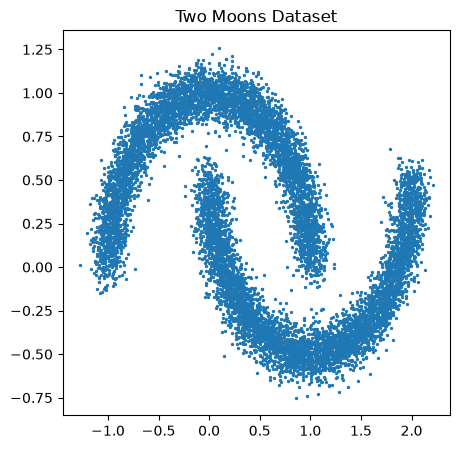

In [19]:
plt.figure(figsize=(5, 5))
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=2)
plt.title("Two Moons Dataset")
plt.show()

## Task 3.2: Define a Small Network for Coupling Layers

In [20]:
class CouplingNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

## Task 3.3: Implement an Affine Coupling Layer

For a 2D vector \(x=(x_1,x_2)\), keep one coordinate fixed and transform the other.

In [21]:
class AffineCoupling(nn.Module):
    def __init__(self, flip=False):
        super().__init__()
        self.flip = flip
        self.nn = CouplingNN(input_dim=1, output_dim=2)

    def forward(self, x):
        if self.flip:
            x = torch.flip(x, dims=[1])

        x1 = x[:, :1]
        x2 = x[:, 1:]

        st = self.nn(x1)
        s, t = st[:, :1], st[:, 1:]
        s = torch.tanh(s)

        y1 = x1
        y2 = x2 * torch.exp(s) + t

        y = torch.cat([y1, y2], dim=1)

        if self.flip:
            y = torch.flip(y, dims=[1])

        log_det = s.squeeze(1)

        return y, log_det

    def inverse(self, y):
        if self.flip:
            y = torch.flip(y, dims=[1])

        y1 = y[:, :1]
        y2 = y[:, 1:]

        st = self.nn(y1)
        s, t = st[:, :1], st[:, 1:]
        s = torch.tanh(s)

        x1 = y1
        x2 = (y2 - t) * torch.exp(-s)

        x = torch.cat([x1, x2], dim=1)

        if self.flip:
            x = torch.flip(x, dims=[1])

        log_det = -s.squeeze(1)

        return x, log_det

## Task 3.4: Implement the Full Flow

In [22]:
class RealNVP2D(nn.Module):
    def __init__(self, num_layers=6):
        super().__init__()

        self.layers = nn.ModuleList([
            AffineCoupling(flip=(i % 2 == 1))
            for i in range(num_layers)
        ])

    def base_log_prob(self, z):
        return -0.5 * (z.pow(2).sum(dim=1) + 2 * np.log(2 * np.pi))

    def sample_base(self, num_samples):
        return torch.randn(num_samples, 2).to(device)

    def forward(self, z):
        log_det_total = torch.zeros(z.size(0)).to(device)

        x = z
        for layer in self.layers:
            x, log_det = layer.forward(x)
            log_det_total += log_det

        return x, log_det_total

    def inverse(self, x):
        log_det_total = torch.zeros(x.size(0)).to(device)

        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total += log_det

        return z, log_det_total

    def log_prob(self, x):
        z, log_det = self.inverse(x)
        return self.base_log_prob(z) + log_det

    def sample(self, num_samples):
        z = self.sample_base(num_samples)
        x, _ = self.forward(z)
        return x

## Task 3.5: Train the Flow by Maximum Likelihood

In [23]:
flow = RealNVP2D(num_layers=6).to(device)
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)

data_2d = data_2d.to(device)
dataset_2d = torch.utils.data.TensorDataset(data_2d)
loader_2d = DataLoader(dataset_2d, batch_size=256, shuffle=True)

num_epochs = 100
flow_nll_curve = []

for epoch in range(num_epochs):
    flow.train()
    total_loss = 0

    for batch in loader_2d:
        x = batch[0]

        loss = -flow.log_prob(x).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader_2d)
    flow_nll_curve.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, NLL: {avg_loss:.4f}")

Epoch 10, NLL: 0.9745
Epoch 20, NLL: 0.9434
Epoch 30, NLL: 0.9116
Epoch 40, NLL: 0.8992
Epoch 50, NLL: 0.8957
Epoch 60, NLL: 0.8984
Epoch 70, NLL: 0.8661
Epoch 80, NLL: 0.8637
Epoch 90, NLL: 0.8723
Epoch 100, NLL: 0.8768


## Task 3.6: Sample from the Flow

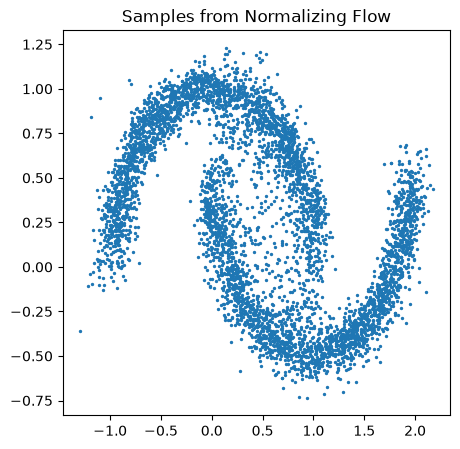

In [24]:
flow.eval()
with torch.no_grad():
    samples = flow.sample(5000).cpu()

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=2)
plt.title("Samples from Normalizing Flow")
plt.show()

## Task 3.7: Visualize Learned Density

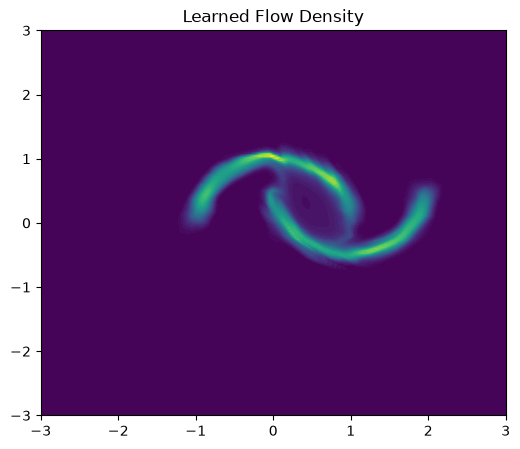

In [25]:
def plot_flow_density(flow, lim=3, n=200):
    x = torch.linspace(-lim, lim, n)
    y = torch.linspace(-lim, lim, n)

    xx, yy = torch.meshgrid(x, y, indexing="ij")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

    with torch.no_grad():
        log_prob = flow.log_prob(grid)
        prob = torch.exp(log_prob).cpu().reshape(n, n)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx.numpy(), yy.numpy(), prob.numpy(), levels=50)
    plt.title("Learned Flow Density")
    plt.show()

plot_flow_density(flow)

## Questions: Normalizing Flows

Answer in your report:

1. Why must the transformation in a normalizing flow be invertible?
2. Why do \(x\) and \(z\) need to have the same dimension?
3. What is the role of the Jacobian determinant?
4. Why are triangular or coupling-layer Jacobians computationally useful?

# Part 5: Required Experiments

Implement and run the following experiments and report the results.

## Experiment 1: Autoregressive Hidden Size

Train autoregressive models with:

```python
hidden_dims = [128, 512, 1024]
```

Report:

1. Train NLL.
2. Test NLL.
3. Sample quality.

## Experiment 2: VAE Latent Dimension

Train VAEs with:

```python
latent_dims = [2, 10, 20, 50]
```

Report:

1. Reconstruction loss.
2. KL divergence.
3. Sample quality.
4. Latent interpolation results.

## Experiment 3: Flow Depth

Train flows with:

```python
num_layers = [2, 4, 8, 12]
```

Report:

1. Negative log-likelihood.
2. Density visualization.
3. Sample quality.
4. Whether deeper flows improve the learned distribution.